## Yellow-legged hornet model

11 - Patch construction

12 - Grid Search

**13 - PSO**

14 - Simulation

15 - Map

Spatial Division 1

 Region 1: France

 Region 2: others

**Spatial Division 2**

 Region 1: France _+ Portugal

 Region 2: others


ref: https://pyswarms.readthedocs.io/en/latest/intro.html

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
 !pip install pyswarms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
import pyswarms as ps
from pyswarms.utils.functions import single_obj as fx
from pyswarms.utils.plotters import (plot_cost_history, plot_contour, plot_surface)

In [ ]:
patch_df = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_patch_attributes_V5.csv")

D_ij = np.load("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_D_shortest_global_V5.npy")

In [ ]:
patch_df.head()

,patch_id,cell_area,land_area,land_prop,A_i,occyear1,occyear2,region
0,0,400000000.0,1.796594e+08,0.449148,179.659369,0,0,1
1,1,400000000.0,3.588828e+08,0.897207,358.882792,0,0,1
2,2,400000000.0,2.328088e+08,0.582022,232.808759,1,1,2
3,3,400000000.0,2.426348e+08,0.606587,242.634810,1,1,2
4,4,400000000.0,1.125199e+08,0.281300,112.519858,1,1,2


In [ ]:
patch_df.columns

Index(['patch_id', 'cell_area', 'land_area', 'land_prop', 'A_i', 'occyear1',
       'occyear2', 'region'],
      dtype='object')

In [ ]:
O_j = patch_df["occyear1"].to_numpy(dtype=float)
obsyear2 = patch_df["occyear2"].to_numpy(dtype=float)

A_j = patch_df["A_i"].to_numpy(dtype=float)

land_area = patch_df["land_area"].to_numpy(dtype=float)
land_prop = patch_df["land_prop"].to_numpy(dtype=float)

patch_id = patch_df["patch_id"].to_numpy()
region = patch_df["region"].to_numpy()

In [ ]:
print("n patches =", len(patch_id))
print("occupied year1 =", int(O_j.sum()))
print("occupied year2 =", int(obsyear2.sum()))

n patches = 2567
occupied year1 = 866
occupied year2 = 794


In [ ]:
### null model RMSE

rmse_null = np.sqrt(np.mean((obsyear2-0)**2))
print("Null model RMSE:", rmse_null)

Null model RMSE: 0.5561568835846148


$$
\begin{aligned}
S_i &= \sum_{j\neq i}\exp(-\alpha d_{ij})p_jA_j, \\
C_i &= \frac{S_i^2}{S_i^2+y^2}, \\
E_i &= \min\left[\frac{e}{A_i^x},\,1\right], \\
p_i &= \frac{C_i}{C_i+(1-C_i)\frac{e}{A_i^x}}.
\end{aligned}
$$

$$
\alpha_i =
\begin{cases}
\alpha(\mathrm{reg1}), & i \in \mathrm{reg1}, \\
\alpha(\mathrm{reg2}), & i \in \mathrm{reg2}.
\end{cases}
$$

$$
y_i =
\begin{cases}
y(\mathrm{reg1}), & i \in \mathrm{reg1}, \\
y(\mathrm{reg2}), & i \in \mathrm{reg2}.
\end{cases}
$$

$$
e_i =
\begin{cases}
e(\mathrm{reg1}), & i \in \mathrm{reg1}, \\
e(\mathrm{reg2}), & i \in \mathrm{reg2}.
\end{cases}
$$

$$
x_i =
\begin{cases}
x(\mathrm{reg1}), & i \in \mathrm{reg1}, \\
x(\mathrm{reg2}), & i \in \mathrm{reg2}.
\end{cases}
$$


$$
\begin{aligned}
& S_i(\mathrm{year1})
=
\sum_{j\neq i}
\exp(-\alpha_i d_{ij})
p_j(\mathrm{year1})A_j
\\[8pt]
& C_i(\mathrm{year1})
=
\frac{\left[S_i(\mathrm{year1})\right]^2}
{\left[S_i(\mathrm{year1})\right]^2+y_i^2}
\\[8pt]
& E_i(\mathrm{year1})
=
\min\left[
\frac{e_i}{A_i^{x_i}},
\,1
\right]
\\[8pt]
& p_i(\mathrm{year2})
=
\frac{C_i(\mathrm{year1})}
{C_i(\mathrm{year1})
+\left[1-C_i(\mathrm{year1})\right]E_i(\mathrm{year1})}
\end{aligned}
$$



---



# PSO

In [ ]:
## Define IFM Function:

def run_ifm_rmse(alpha_reg1,  y_reg1, e_reg1, x_reg1,
                 alpha_reg2, y_reg2, e_reg2, x_reg2):

## if i in region 1, use parameters of region 1, else use parameters of region 2

    alpha_i = np.where( region == 1, alpha_reg1, alpha_reg2)

    y_i = np.where(region == 1, y_reg1,  y_reg2)

    e_i = np.where(region == 1, e_reg1, e_reg2)

    x_i = np.where(region == 1, x_reg1, x_reg2)


    K_ij = np.exp(-alpha_i[:, None] * D_ij)

    np.fill_diagonal(K_ij, 0.0)

  # year 1
    S_i_year1 = K_ij @ ( O_j * A_j)

    C_i_year1 = ( S_i_year1 ** 2 / ( S_i_year1 ** 2 + y_i ** 2 ))

    E_i_year1 = np.minimum( e_i / (A_j ** x_i), 1.0)

  # to year 2
    p_i_year2 = ( C_i_year1 / ( C_i_year1 + (1 - C_i_year1) * E_i_year1))


  # define rmse
    rmse = np.sqrt(np.mean((p_i_year2 - obsyear2) ** 2))

    return (rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1)


In [ ]:
def objective(params):

    costs = []

    for (
        alpha_reg1,
        y_reg1,
        e_reg1,
        x_reg1,

        alpha_reg2,
        y_reg2,
        e_reg2,
        x_reg2
    ) in params:

        rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(
            alpha_reg1,
            y_reg1,
            e_reg1,
            x_reg1,

            alpha_reg2,
            y_reg2,
            e_reg2,
            x_reg2
        )

        n_pred = np.count_nonzero(p_i_year2 > 0.5)

        penalty = 0.0
        # penalty = 0.001 * abs(n_pred - 794)

        costs.append(rmse + penalty)

    return np.array(costs, dtype=float)

#

---

# TEST MULTIPLE SEED

# More social - Round 1

In [ ]:
lower_bounds = np.array([0.1, 0.1, 0.001, 0.1,
                         0.1, 0.1, 0.001, 0.1])

upper_bounds = np.array([2, 100,  10, 20,
                         2, 100,  10, 20])

bounds = (lower_bounds, upper_bounds)

In [ ]:
## More social

%%time

options = {
    "c1": 0.7,     # cognitive parameter
    "c2": 1.5,     # social parameter
    "w": 0.5       # inertia weight
}

seeds = [42, 137, 2026, 123, 234, 456, 678, 890, 1024, 2048]

results = []
history_results = []

# Save paths
result_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_pso_V5_more_social.csv"
history_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_pso_V5_more_social_cost_history.csv"

for seed in seeds:

    np.random.seed(seed)

    optimizer = ps.single.GlobalBestPSO(
        n_particles=300,   ###
        dimensions=8,
        options=options,
        bounds=bounds
    )

    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=50
    )

    # save result

    results.append([
        seed,
        best_cost,
        *best_pos
    ])

    result_df = pd.DataFrame(
        results,
        columns=[
            "seed",
            "rmse",

            "alpha_reg1",
            "y_reg1",
            "e_reg1",
            "x_reg1",

            "alpha_reg2",
            "y_reg2",
            "e_reg2",
            'x_reg2'
        ]
    )

    result_df.to_csv(
        result_path,
        index=False
    )

    # save history

    for iteration, cost in enumerate(
        optimizer.cost_history,
        start=1
    ):
        history_results.append([
            seed,
            iteration,
            cost
        ])

    history_df = pd.DataFrame(
        history_results,
        columns=[
            "seed",
            "iteration",
            "best_rmse"
        ]
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    print(f"\nSeed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)


2026-08-15 23:38:34,077 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.402
2026-08-16 00:31:49,305 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.4015060939849781, best pos: [ 1.04163366 74.53649357  6.51586122  6.31402103  0.76943948  3.54968657
  0.11874265  5.23501003]
2026-08-16 00:31:49,341 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}



Seed 42
Best RMSE: 0.4015060939849781
Best params: [ 1.04163366 74.53649357  6.51586122  6.31402103  0.76943948  3.54968657
  0.11874265  5.23501003]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.4
2026-08-16 01:18:59,629 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3999736019552856, best pos: [ 0.39535551 45.31716964  0.7800358   1.48009101  1.53546732 48.59635041
  3.00081208 13.87253842]
2026-08-16 01:18:59,650 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}



Seed 137
Best RMSE: 0.3999736019552856
Best params: [ 0.39535551 45.31716964  0.7800358   1.48009101  1.53546732 48.59635041
  3.00081208 13.87253842]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.395
2026-08-16 02:08:12,053 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3954135743621005, best pos: [ 0.8541878  25.47842376  4.63189493  4.67033877  0.1018698  40.05408851
  4.9911096   0.19292532]
2026-08-16 02:08:12,083 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}



Seed 2026
Best RMSE: 0.3954135743621005
Best params: [ 0.8541878  25.47842376  4.63189493  4.67033877  0.1018698  40.05408851
  4.9911096   0.19292532]


pyswarms.single.global_best:  94%|█████████▍|47/50, best_cost=0.4

In [ ]:
## More social

%%time

options = {
    "c1": 0.7,     # cognitive parameter
    "c2": 1.5,     # social parameter
    "w": 0.5       # inertia weight
}

seeds = [123, 234, 456, 678, 890, 1024, 2048]

results = []
history_results = []

# Save paths
result_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_pso_V5_more_social.csv"
history_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_pso_V5_more_social_cost_history.csv"

for seed in seeds:

    np.random.seed(seed)

    optimizer = ps.single.GlobalBestPSO(
        n_particles=300,   ###
        dimensions=8,
        options=options,
        bounds=bounds
    )

    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=50
    )

    # save result

    results.append([
        seed,
        best_cost,
        *best_pos
    ])

    result_df = pd.DataFrame(
        results,
        columns=[
            "seed",
            "rmse",

            "alpha_reg1",
            "y_reg1",
            "e_reg1",
            "x_reg1",

            "alpha_reg2",
            "y_reg2",
            "e_reg2",
            'x_reg2'
        ]
    )

    result_df.to_csv(
        result_path,
        index=False
    )

    # save history

    for iteration, cost in enumerate(
        optimizer.cost_history,
        start=1
    ):
        history_results.append([
            seed,
            iteration,
            cost
        ])

    history_df = pd.DataFrame(
        history_results,
        columns=[
            "seed",
            "iteration",
            "best_rmse"
        ]
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    print(f"\nSeed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)


2026-08-16 09:29:24,705 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.4
2026-08-16 10:17:39,556 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.40007818782811233, best pos: [ 0.40996195 36.31637872  4.17330585  1.78622778  0.89958099 56.21763273
  6.06948994  8.05165806]
2026-08-16 10:17:40,188 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}



Seed 123
Best RMSE: 0.40007818782811233
Best params: [ 0.40996195 36.31637872  4.17330585  1.78622778  0.89958099 56.21763273
  6.06948994  8.05165806]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.404
2026-08-16 11:11:35,964 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.4039334430244536, best pos: [ 1.95575233 73.17519918  2.07390259 12.21217774  0.89403476 28.22988728
  5.74117708  7.7510031 ]
2026-08-16 11:11:35,989 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}



Seed 234
Best RMSE: 0.4039334430244536
Best params: [ 1.95575233 73.17519918  2.07390259 12.21217774  0.89403476 28.22988728
  5.74117708  7.7510031 ]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.4
2026-08-16 12:00:34,510 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.4002522677537272, best pos: [ 0.49665627 79.14854577  7.21932474  2.72014345  0.77068056  6.33719744
  7.04667492  6.1310941 ]
2026-08-16 12:00:34,534 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


...


Seed 890
Best RMSE: 0.39932037025741834
Best params: [ 0.40294019 43.57657022  3.85489142  1.78609543  0.82910215  0.88406732
  4.93899392  5.97211515]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.396
2026-08-16 14:32:23,689 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.396171762475054, best pos: [ 1.12587272 88.58574334  4.30522644  6.85695052  0.10622293 57.65833556
  6.58978271  0.42357615]
2026-08-16 14:32:23,718 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}



Seed 1024
Best RMSE: 0.396171762475054
Best params: [ 1.12587272 88.58574334  4.30522644  6.85695052  0.10622293 57.65833556
  6.58978271  0.42357615]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.398
2026-08-16 15:25:40,655 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.39775095240394415, best pos: [ 1.66421639 76.25707719  6.92140914 10.47735159  0.11028263 52.38354817
  5.93778997  0.13147254]



Seed 2048
Best RMSE: 0.39775095240394415
Best params: [ 1.66421639 76.25707719  6.92140914 10.47735159  0.11028263 52.38354817
  5.93778997  0.13147254]
CPU times: user 7h 58min 50s, sys: 37min 44s, total: 8h 36min 35s
Wall time: 5h 56min 15s


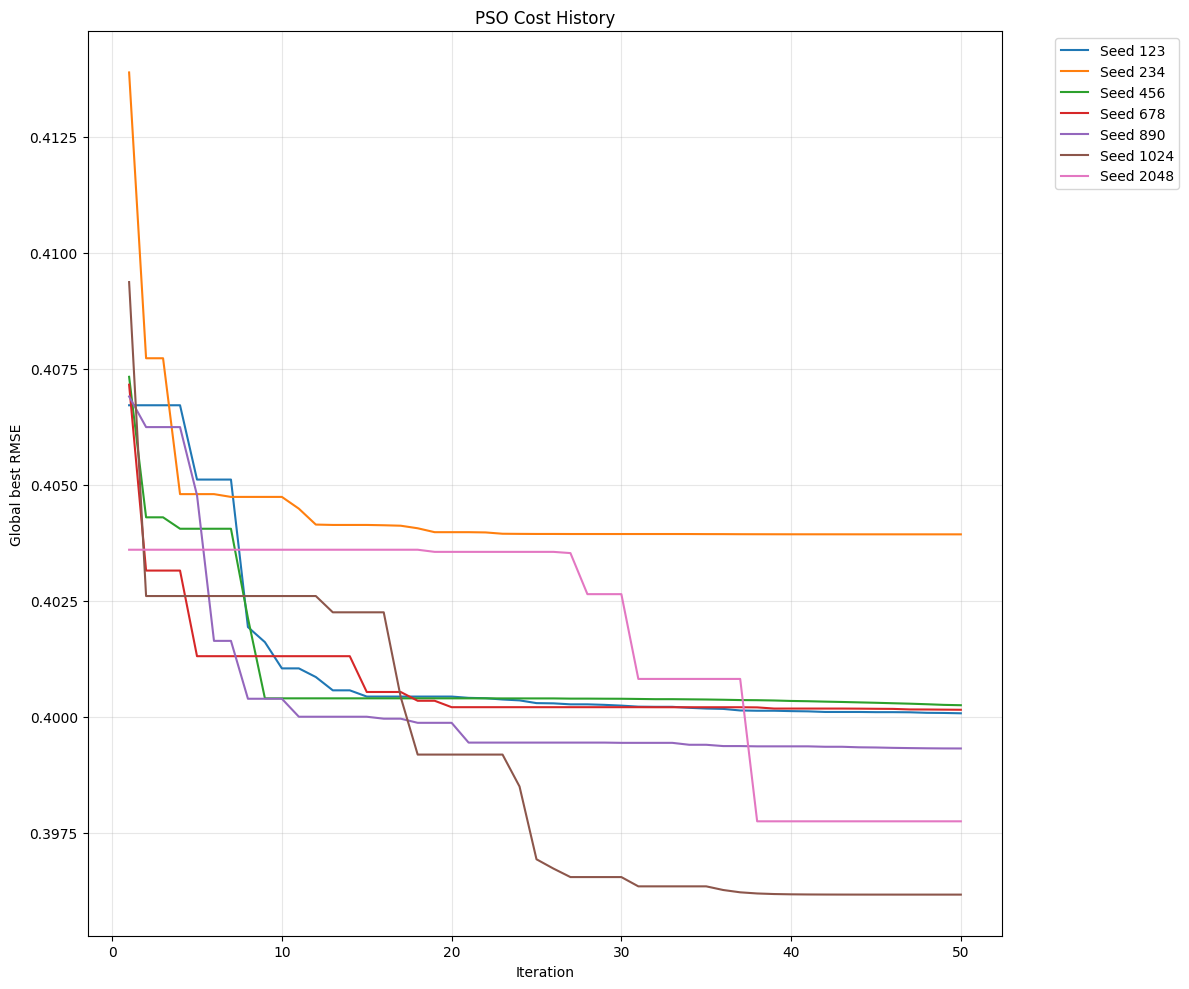

In [ ]:
# more social cost history round 1

plt.figure(figsize=(12, 10))

for seed in seeds:
    df_seed = history_df[
        history_df["seed"] == seed
    ]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(*best_pos)

print(p_i_year2.mean())
print(S_i_year1.mean())
print(C_i_year1.mean())
print(E_i_year1.mean(),"\n")

print(np.count_nonzero(p_i_year2[region == 1] > 0.5),"\n")
print(np.count_nonzero(p_i_year2[region != 1]> 0.5),"\n")


print(p_i_year2[region == 1].mean())
print(p_i_year2[region != 1].mean(),"\n")

print(S_i_year1[region == 1].mean())
print(S_i_year1[region != 1].mean(),"\n")

print(C_i_year1[region == 1].mean())
print(C_i_year1[region != 1].mean(),"\n")

print(E_i_year1[region == 1].mean())
print(E_i_year1[region != 1].mean())


0.25223901068883703
15.032526778199125
0.07521152661636121
0.3899493572266267 

460 

207 

0.28944557427646206
0.1936489356310925 

4.777043830333495e-09
38.70461006232417 

1.6142453675103772e-18
0.1936489356310925 

0.002547770701115194
1.0


# More social round 2

In [ ]:
# Hornet V6 more Social Round 2

%%time

# previous best fittings
seed_pos = np.array([
    0.8541878,  25.47842376,  4.63189493,  4.67033877,
    0.1018698,  40.05408851,  4.9911096,  0.19292532

])


options = {
    "c1": 0.7,       # cognitive parameter
    "c2": 1.5,       # social parameter
    "w": 0.5
}


lower_bounds = np.array([0.1, 1, 0.1, 1,
                         0.05, 0.1, 0.001, 0.1])

upper_bounds = np.array([2, 100,  10, 20,
                         2, 80,  10, 15])

bounds = (lower_bounds, upper_bounds)



n_particles = 200
dimensions = 8
n_iterations = 50


result_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"   "hornet_pso_V5_more_social_round2.csv")

history_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"   "hornet_pso_V5_more_social_round2_cost_history.csv")


results = []
history_results = []


seeds = [42, 137, 2026, 123, 234, 456, 678, 890, 1024, 2048]


for seed in seeds:

    np.random.seed(seed)

    init_pos = np.random.uniform(
        low=lower_bounds,
        high=upper_bounds,
        size=(n_particles, dimensions)
    )

    init_pos[0] = seed_pos


    optimizer = ps.single.GlobalBestPSO(
        n_particles=n_particles,
        dimensions=dimensions,
        options=options,
        bounds=bounds,
        init_pos=init_pos
    )


    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=n_iterations
    )


    results.append([
        seed,
        best_cost,
        *best_pos
    ])


    result_df = pd.DataFrame(
        results,
        columns=[
            "seed",
            "rmse",

            "alpha_reg1",
            "y_reg1",
            "e_reg1",
            "x_reg1",

            "alpha_reg2",
            "y_reg2",
            "e_reg2",
            "x_reg2"
        ]
    )

    result_df.to_csv(
        result_path,
        index=False
    )


    for iteration, cost in enumerate(
        optimizer.cost_history,
        start=1 ):

        history_results.append([seed, iteration, cost])


    history_df = pd.DataFrame(history_results, columns=["seed", "iteration", "best_rmse"])

    history_df.to_csv(history_path, index=False)


    print(f"Seed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)
    print("Initial position shape:", init_pos.shape)
    print()


2026-08-16 18:43:09,654 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.395
2026-08-16 19:17:22,087 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.39510751804840705, best pos: [ 0.8571671  25.50807072  4.63085267  4.67074719  0.1040409  40.06364478
  4.98987803  0.14550583]
2026-08-16 19:17:22,147 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


Seed 42
Best RMSE: 0.39510751804840705
Best params: [ 0.8571671  25.50807072  4.63085267  4.67074719  0.1040409  40.06364478
  4.98987803  0.14550583]
Initial position shape: (200, 8)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.395
2026-08-16 19:51:06,268 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.39534612352277687, best pos: [ 0.85488365 25.4117254   4.68111828  4.67405578  0.10479414 40.05342887
  4.99109421  0.1307599 ]
2026-08-16 19:51:06,298 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


Seed 137
Best RMSE: 0.39534612352277687
Best params: [ 0.85488365 25.4117254   4.68111828  4.67405578  0.10479414 40.05342887
  4.99109421  0.1307599 ]
Initial position shape: (200, 8)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.395
2026-08-16 20:24:47,488 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3951051626104512, best pos: [ 0.85438146 27.37577743  4.63520613  4.6755194   0.10352966 40.00187384
  4.99033637  0.19267805]
2026-08-16 20:24:47,510 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


Seed 2026
Best RMSE: 0.3951051626104512
Best params: [ 0.85438146 27.37577743  4.63520613  4.6755194   0.10352966 40.00187384
  4.99033637  0.19267805]
Initial position shape: (200, 8)



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.395
2026-08-16 20:58:34,730 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3952095129824502, best pos: [ 0.85720318 26.26648113  4.6276244   4.67054614  0.10068134 40.0217989
  4.99646716  0.22848876]
2026-08-16 20:58:34,759 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


Seed 123
Best RMSE: 0.3952095129824502
Best params: [ 0.85720318 26.26648113  4.6276244   4.67054614  0.10068134 40.0217989
  4.99646716  0.22848876]
Initial position shape: (200, 8)



pyswarms.single.global_best:  60%|██████    |30/50, best_cost=0.395

In [ ]:
%%time

seed_pos = np.array([
    0.8541878, 25.47842376, 4.63189493, 4.67033877,
    0.1018698, 40.05408851, 4.9911096, 0.19292532
])

options = {
    "c1": 0.7,    # cognitive parameter
    "c2": 1.5,    # social parameter
    "w": 0.5
}

lower_bounds = np.array([ 0.1, 1, 0.1, 1,   0.05, 0.1, 0.001, 0.1])

upper_bounds = np.array([ 2, 100, 10, 20,   2, 80, 10, 15])

bounds = (lower_bounds, upper_bounds)

n_particles = 200
dimensions = 8
n_iterations = 50

result_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/" "hornet_pso_V5_more_social_round2.csv")

history_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
"hornet_pso_V5_more_social_round2_cost_history.csv")


result_df = pd.read_csv(result_path)
history_df = pd.read_csv(history_path)


seeds = [2026, 123, 234, 456, 678, 890, 1024, 2048]


for seed in seeds:

    np.random.seed(seed)

    init_pos = np.random.uniform(
        low=lower_bounds,
        high=upper_bounds,
        size=(n_particles, dimensions)
    )

    init_pos[0] = seed_pos

    optimizer = ps.single.GlobalBestPSO(
        n_particles=n_particles,
        dimensions=dimensions,
        options=options,
        bounds=bounds,
        init_pos=init_pos
    )

    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=n_iterations
    )

    new_result = pd.DataFrame(
        [[seed, best_cost, *best_pos]],
        columns=[
            "seed", "rmse",
            "alpha_reg1", "y_reg1", "e_reg1", "x_reg1",
            "alpha_reg2", "y_reg2", "e_reg2", "x_reg2"
        ]
    )

    result_df = result_df[result_df["seed"] != seed]
    result_df = pd.concat([result_df, new_result], ignore_index=True)
    result_df.to_csv(result_path, index=False)

    new_history = pd.DataFrame(
        [[seed, iteration, cost]
         for iteration, cost in enumerate(optimizer.cost_history, start=1)],
        columns=["seed", "iteration", "best_rmse"]
    )

    history_df = history_df[history_df["seed"] != seed]
    history_df = pd.concat([history_df, new_history], ignore_index=True)
    history_df.to_csv(history_path, index=False)

    print(f"Seed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)
    print()

2026-08-16 23:32:01,903 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.395
2026-08-17 00:04:41,223 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3951051626104512, best pos: [ 0.85438146 27.37577743  4.63520613  4.6755194   0.10352966 40.00187384
  4.99033637  0.19267805]
2026-08-17 00:04:41,268 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


Seed 2026
Best RMSE: 0.3951051626104512
Best params: [ 0.85438146 27.37577743  4.63520613  4.6755194   0.10352966 40.00187384
  4.99033637  0.19267805]



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.395
2026-08-17 00:37:16,990 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3952095129824502, best pos: [ 0.85720318 26.26648113  4.6276244   4.67054614  0.10068134 40.0217989
  4.99646716  0.22848876]
2026-08-17 00:37:17,020 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


Seed 123
Best RMSE: 0.3952095129824502
Best params: [ 0.85720318 26.26648113  4.6276244   4.67054614  0.10068134 40.0217989
  4.99646716  0.22848876]



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.395
2026-08-17 01:10:14,254 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3951177913737474, best pos: [ 0.8597989  25.54759042  4.2925231   4.67697027  0.10457225 40.05587313
  4.98386353  0.16549027]
2026-08-17 01:10:14,279 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


...

Seed 890
Best RMSE: 0.39511689640990905
Best params: [ 0.84733149 28.13911647  5.05729363  4.64402835  0.10567538 40.18506455
  5.07315432  0.22519527]



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.395
2026-08-17 03:20:47,465 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.39509539290302087, best pos: [ 0.85642364 25.3657254   4.69054843  4.6630622   0.10432139 40.31742618
  5.00849504  0.21713775]
2026-08-17 03:20:47,491 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 0.7, 'c2': 1.5, 'w': 0.5}


Seed 1024
Best RMSE: 0.39509539290302087
Best params: [ 0.85642364 25.3657254   4.69054843  4.6630622   0.10432139 40.31742618
  5.00849504  0.21713775]



pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.395
2026-08-17 03:53:27,308 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.39506586266108606, best pos: [ 0.83369722 25.60443229  4.54252566  4.51371251  0.10682677 40.3824062
  4.9302832   0.19338199]


Seed 2048
Best RMSE: 0.39506586266108606
Best params: [ 0.83369722 25.60443229  4.54252566  4.51371251  0.10682677 40.3824062
  4.9302832   0.19338199]

CPU times: user 5h 56min 11s, sys: 28min 26s, total: 6h 24min 38s
Wall time: 4h 21min 26s


In [ ]:
result_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/" "hornet_pso_V5_more_social_round2.csv")
history_path = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
"hornet_pso_V5_more_social_round2_cost_history.csv")

seeds = [42, 137, 2026, 123, 234, 456, 678, 890, 1024, 2048]

result_df = pd.read_csv(result_path)
history_df = pd.read_csv(history_path)

In [ ]:
best_row = result_df.loc[result_df["rmse"].idxmin()]

best_pos = best_row[["alpha_reg1",  "y_reg1",  "e_reg1", "x_reg1",
                     "alpha_reg2",  "y_reg2",  "e_reg2", "x_reg2"]].to_numpy(dtype=float)

print(best_pos)

[ 0.83369722 25.60443229  4.54252566  4.51371251  0.10682677 40.3824062
  4.9302832   0.19338199]


In [ ]:
# more social cost history round 2

rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(*best_pos)

print(p_i_year2.mean())
print(S_i_year1.mean())
print(C_i_year1.mean())
print(E_i_year1.mean(),"\n")

print(np.count_nonzero(p_i_year2[region == 1] > 0.5),"\n")
print(np.count_nonzero(p_i_year2[region != 1]> 0.5),"\n")


print(p_i_year2[region == 1].mean())
print(p_i_year2[region != 1].mean(),"\n")

print(S_i_year1[region == 1].mean())
print(S_i_year1[region != 1].mean(),"\n")

print(C_i_year1[region == 1].mean())
print(C_i_year1[region != 1].mean(),"\n")

print(E_i_year1[region == 1].mean())
print(E_i_year1[region != 1].mean())


0.25954896228044855
16.415541445917498
0.08365257532846418
0.38994955820190624 

449 

227 

0.2875961970397618
0.21538230373268347 

0.00019315492595374954
42.26518720003657 

2.5775045467746508e-09
0.21538230373268347 

0.002548099302097738
1.0


In [ ]:
parameter_cols = ["alpha_reg1",  "y_reg1", "e_reg1", "x_reg1",
                  "alpha_reg2", "y_reg2", "e_reg2", "x_reg2"]

summary_results = []

for _, row in result_df.iterrows():

    pos = row[parameter_cols].to_numpy(dtype=float)

    rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(*pos)

    reg1 = (region == 1)
    reg2 = (region != 1)

    summary_results.append({
        "seed": row["seed"],
        "rmse": rmse,

        "mean_p_all": p_i_year2.mean(),
        "mean_S_all": S_i_year1.mean(),
        "mean_C_all": C_i_year1.mean(),
        "mean_E_all": E_i_year1.mean(),

        "n_pred_reg1": np.count_nonzero(p_i_year2[reg1] > 0.5),
        "mean_p_reg1": p_i_year2[reg1].mean(),
        "mean_S_reg1": S_i_year1[reg1].mean(),
        "mean_C_reg1": C_i_year1[reg1].mean(),
        "mean_E_reg1": E_i_year1[reg1].mean(),

        "n_pred_reg2": np.count_nonzero(p_i_year2[reg2] > 0.5),
        "mean_p_reg2": p_i_year2[reg2].mean(),
        "mean_S_reg2": S_i_year1[reg2].mean(),
        "mean_C_reg2": C_i_year1[reg2].mean(),
        "mean_E_reg2": E_i_year1[reg2].mean(),

    })

summary_df = pd.DataFrame(summary_results)

summary_df = (
    summary_df
    .sort_values("rmse")
    .reset_index(drop=True)
)

summary_df

,seed,rmse,mean_p_all,mean_S_all,mean_C_all,mean_E_all,n_pred_reg1,mean_p_reg1,mean_S_reg1,mean_C_reg1,mean_E_reg1,n_pred_reg2,mean_p_reg2,mean_S_reg2,mean_C_reg2,mean_E_reg2
0,2048.0,0.395066,0.259549,16.415541,0.083653,0.389950,449,0.287596,0.000193,2.577505e-09,0.002548,227,0.215382,42.265187,0.215382,1.0
1,1024.0,0.395095,0.259490,17.511860,0.085331,0.389950,448,0.284757,0.000139,1.524092e-09,0.002548,230,0.219703,45.087991,0.219703,1.0
2,678.0,0.395104,0.260742,17.983583,0.086130,0.389950,449,0.285496,0.000140,1.525170e-09,0.002548,232,0.221762,46.302546,0.221762,1.0
3,2026.0,0.395105,0.261265,17.876133,0.086024,0.389949,449,0.286525,0.000143,1.373927e-09,0.002548,232,0.221488,46.025887,0.221488,1.0
4,42.0,0.395108,0.261146,17.639902,0.085652,0.389949,449,0.286938,0.000137,1.480602e-09,0.002548,231,0.220531,45.417665,0.220531,1.0
5,890.0,0.395117,0.255999,16.909015,0.084512,0.389950,445,0.280387,0.000158,1.539207e-09,0.002548,229,0.217595,43.535801,0.217595,1.0
6,234.0,0.395118,0.261214,17.398274,0.085306,0.389949,449,0.287615,0.000132,1.386123e-09,0.002548,230,0.219640,44.795549,0.219640,1.0
7,456.0,0.395201,0.263383,19.752424,0.088544,0.389949,449,0.285867,0.000137,1.470982e-09,0.002548,236,0.227977,50.856828,0.227977,1.0
8,123.0,0.395210,0.258927,19.263044,0.087921,0.389949,445,0.279601,0.000137,1.395132e-09,0.002548,234,0.226371,49.596808,0.226371,1.0
9,137.0,0.395346,0.268611,17.298539,0.085161,0.389949,511,0.299945,0.000142,1.575493e-09,0.002548,230,0.219267,44.538743,0.219267,1.0


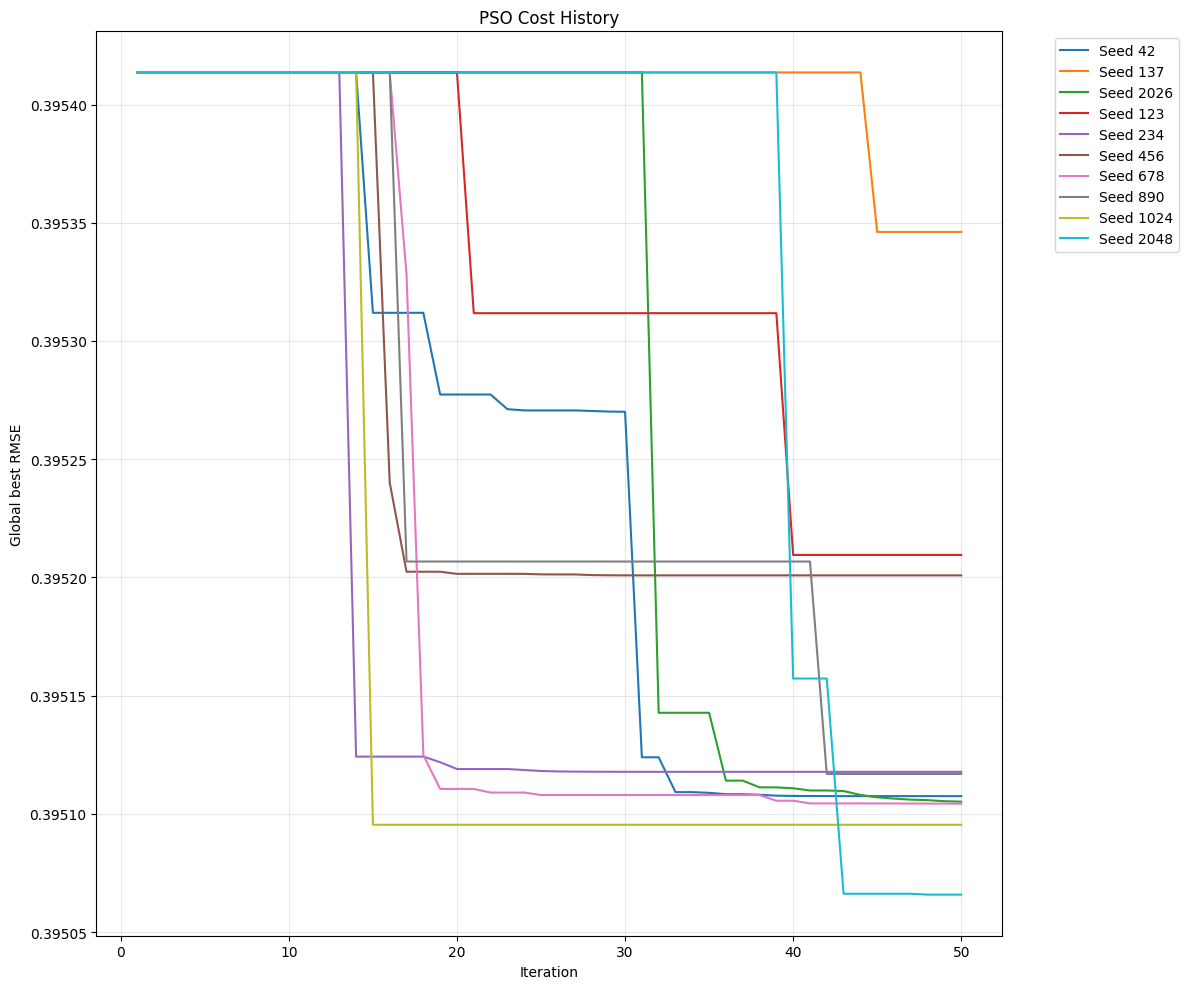

In [ ]:
# more social cost history round 2

plt.figure(figsize=(12, 10))

for seed in seeds:
    df_seed = history_df[history_df["seed"] == seed]

    plt.plot(
        df_seed["iteration"],
        df_seed["best_rmse"],
        label=f"Seed {seed}",
        linewidth=1.5
    )

plt.xlabel("Iteration")
plt.ylabel("Global best RMSE")
plt.title("PSO Cost History")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# More coginitive

In [ ]:
lower_bounds = np.array([0.1, 0.1, 0.001, 0.1,
                         0.1, 0.1, 0.001, 0.1])

upper_bounds = np.array([2, 100,  10, 20,
                         2, 100,  10, 20])

bounds = (lower_bounds, upper_bounds)

In [ ]:
## More cognitive

%%time

options = {
    "c1": 1.5,     # cognitive parameter
    "c2": 0.7,     # social parameter
    "w": 0.5       # inertia weight
}

seeds = [42, 137, 2026, 123, 234, 456, 678, 890, 1024, 2048]

results = []
history_results = []

# Save paths
result_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_pso_V5_more_cognitive.csv"
history_path = "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_pso_V5_more_cognitive_cost_history.csv"

for seed in seeds:

    np.random.seed(seed)

    optimizer = ps.single.GlobalBestPSO(
        n_particles=200,   ###
        dimensions=8,
        options=options,
        bounds=bounds
    )

    best_cost, best_pos = optimizer.optimize(
        objective,
        iters=50
    )

    # save result

    results.append([
        seed,
        best_cost,
        *best_pos
    ])

    result_df = pd.DataFrame(
        results,
        columns=[
            "seed",
            "rmse",

            "alpha_reg1",
            "y_reg1",
            "e_reg1",
            "x_reg1",

            "alpha_reg2",
            "y_reg2",
            "e_reg2",
            'x_reg2'
        ]
    )

    result_df.to_csv(
        result_path,
        index=False
    )

    # save history

    for iteration, cost in enumerate(
        optimizer.cost_history,
        start=1
    ):
        history_results.append([
            seed,
            iteration,
            cost
        ])

    history_df = pd.DataFrame(
        history_results,
        columns=[
            "seed",
            "iteration",
            "best_rmse"
        ]
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    print(f"\nSeed {seed}")
    print("Best RMSE:", best_cost)
    print("Best params:", best_pos)


2026-08-17 10:54:47,838 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.402
2026-08-17 11:32:52,324 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.40213232007680483, best pos: [ 0.93180221 87.8757868   2.41733933  5.4711946   0.73118883 62.23038517
  6.99455102  6.51243465]
2026-08-17 11:32:52,407 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}



Seed 42
Best RMSE: 0.40213232007680483
Best params: [ 0.93180221 87.8757868   2.41733933  5.4711946   0.73118883 62.23038517
  6.99455102  6.51243465]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.4
2026-08-17 12:05:41,843 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.4002366667486802, best pos: [ 0.39278143 75.33273676  4.137793    1.91306135  1.37086204 66.5181637
  6.09609165 12.54199805]
2026-08-17 12:05:41,919 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}



Seed 137
Best RMSE: 0.4002366667486802
Best params: [ 0.39278143 75.33273676  4.137793    1.91306135  1.37086204 66.5181637
  6.09609165 12.54199805]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.401
2026-08-17 12:43:48,862 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.4010470019120606, best pos: [ 0.64142479 59.34156514  4.86898798  3.52393668  0.90969284 49.88822184
  4.06292866  8.02317354]
2026-08-17 12:43:48,902 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}


...


Seed 890
Best RMSE: 0.4021855848020162
Best params: [ 0.98763383 13.8871585   4.21927157  5.31692766  1.372859   51.73556823
  4.28157246 12.44188648]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.4
2026-08-17 16:29:29,694 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.39991412575874963, best pos: [ 0.42943475 23.11128646  3.43249867  1.73247061  1.0229616   5.09400873
  3.06195893  8.29194876]
2026-08-17 16:29:29,722 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 1.5, 'c2': 0.7, 'w': 0.5}



Seed 1024
Best RMSE: 0.39991412575874963
Best params: [ 0.42943475 23.11128646  3.43249867  1.73247061  1.0229616   5.09400873
  3.06195893  8.29194876]


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.402
2026-08-17 17:03:30,441 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.40152053491040257, best pos: [ 0.93992695 56.32223988  6.36853496  5.53941063  0.50883235  9.24172633
  4.47093325  3.71918037]



Seed 2048
Best RMSE: 0.40152053491040257
Best params: [ 0.93992695 56.32223988  6.36853496  5.53941063  0.50883235  9.24172633
  4.47093325  3.71918037]
CPU times: user 7h 54min 7s, sys: 46min 55s, total: 8h 41min 2s
Wall time: 6h 8min 42s
